In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("fcc-forum-pageviews.csv", parse_dates=["date"], index_col="date")

# Remove top and bottom 2.5% of data (outliers)
lower = df["value"].quantile(0.025)
upper = df["value"].quantile(0.975)

df = df[(df["value"] >= lower) & (df["value"] <= upper)]

In [7]:
def draw_line_plot():
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(df.index, df["value"], color="red", linewidth=1)

    ax.set_title("Daily freeCodeCamp Forum Page Views 5/2016-12/2019")
    ax.set_xlabel("Date")
    ax.set_ylabel("Page Views")

    plt.tight_layout()
    return fig

In [8]:
def draw_bar_plot():
    df_bar = df.copy()
    df_bar["year"] = df_bar.index.year
    df_bar["month"] = df_bar.index.month

    df_bar = df_bar.groupby(["year", "month"])["value"].mean().unstack()

    fig = df_bar.plot(kind="bar", figsize=(12, 6)).figure

    plt.xlabel("Years")
    plt.ylabel("Average Page Views")
    plt.legend(title="Months", labels=[
        "Jan","Feb","Mar","Apr","May","Jun",
        "Jul","Aug","Sep","Oct","Nov","Dec"
    ])

    plt.tight_layout()
    return fig

In [9]:
def draw_box_plot():
    df_box = df.copy()
    df_box.reset_index(inplace=True)

    df_box["year"] = df_box["date"].dt.year
    df_box["month"] = df_box["date"].dt.strftime("%b")

    month_order = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.boxplot(x="year", y="value", data=df_box, ax=axes[0])
    axes[0].set_title("Year-wise Box Plot (Trend)")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Page Views")

    sns.boxplot(x="month", y="value", data=df_box, order=month_order, ax=axes[1])
    axes[1].set_title("Month-wise Box Plot (Seasonality)")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Page Views")

    plt.tight_layout()
    return fig

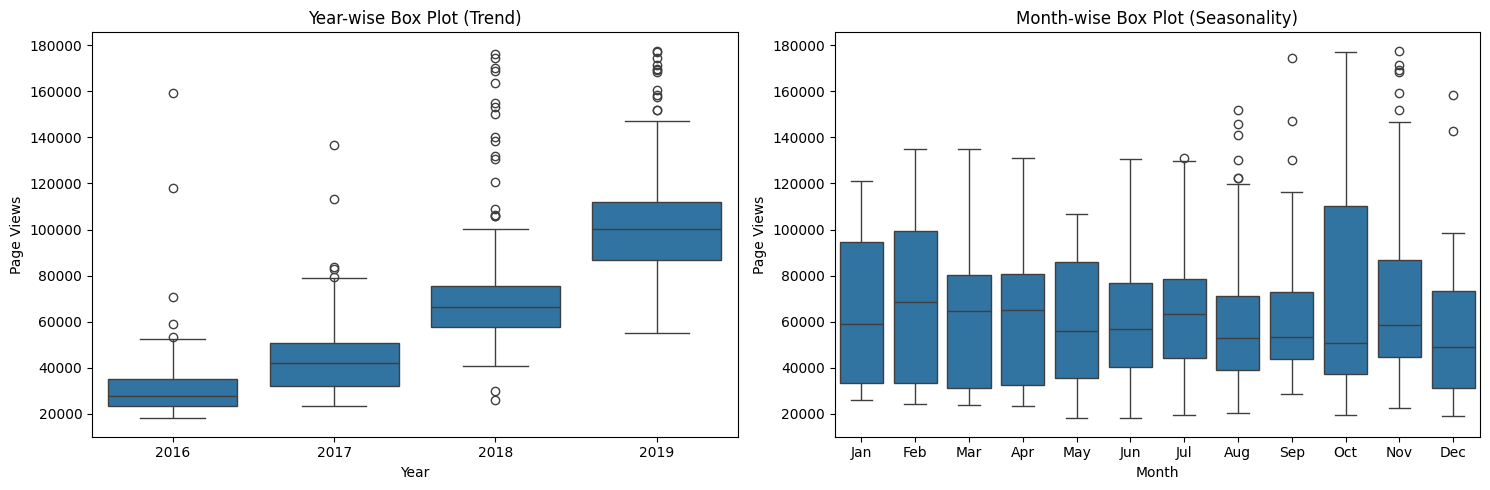

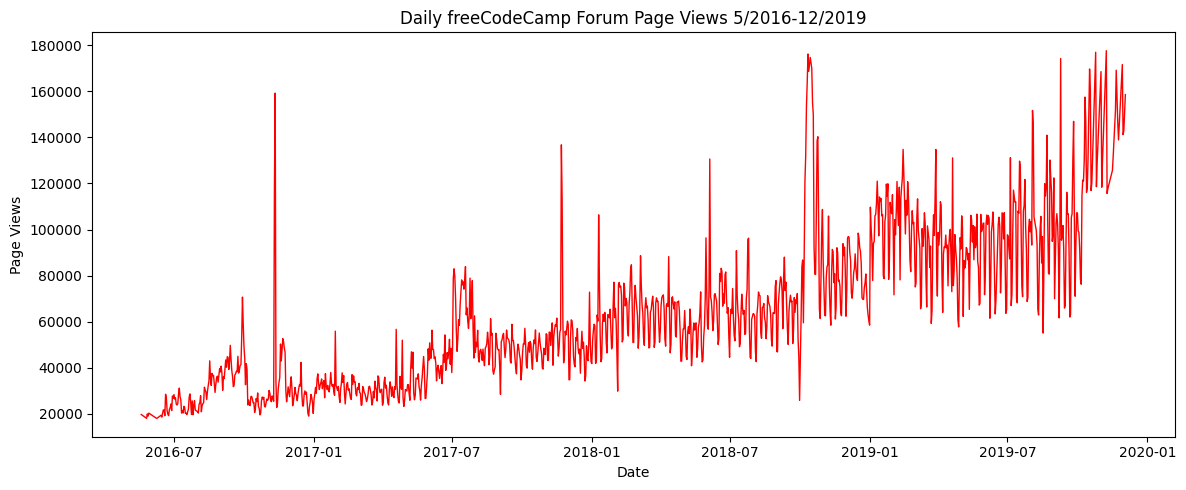

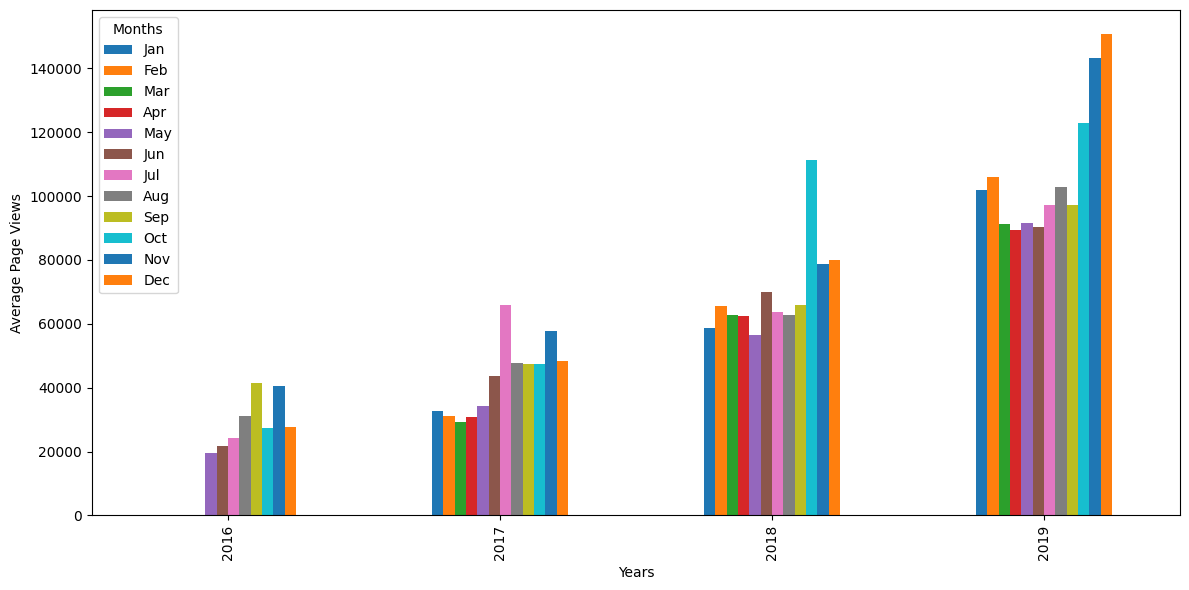

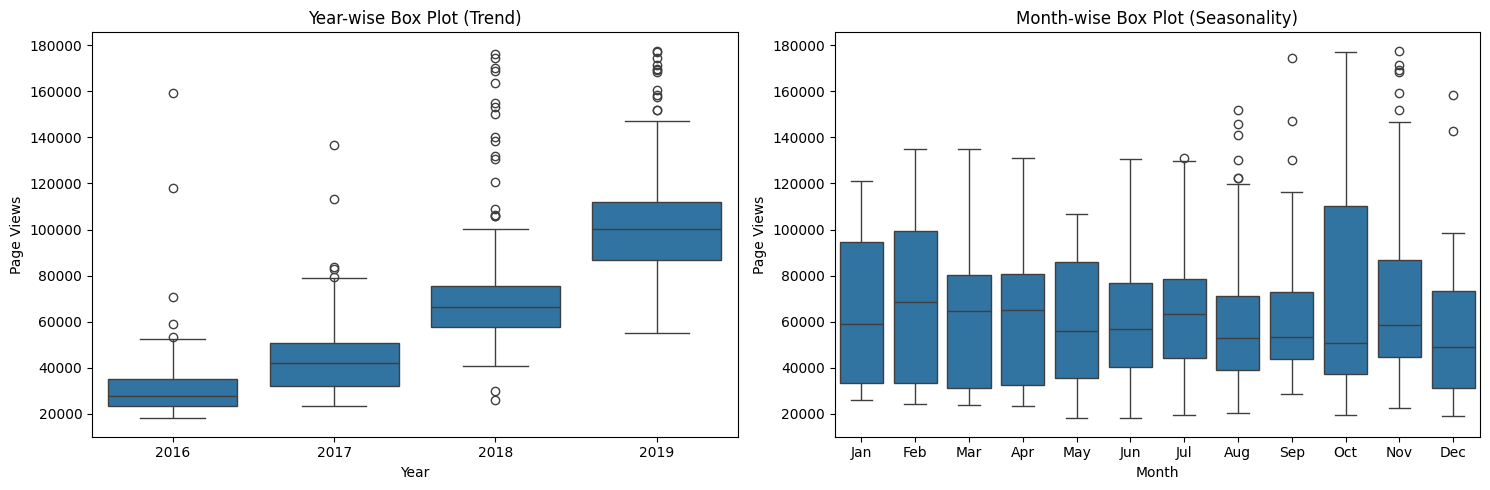

In [10]:
draw_line_plot()
draw_bar_plot()
draw_box_plot()